In [73]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.naive_bayes import CategoricalNB
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import f1_score, classification_report
from ucimlrepo import fetch_ucirepo

In [74]:
# ── Data ──────────────────────────────────────────────────────────────────────
car_evaluation = fetch_ucirepo(id=19)
X_raw = car_evaluation.data.features.copy()
y_raw = car_evaluation.data.targets.copy()

encoder = OrdinalEncoder()
X_encoded = encoder.fit_transform(X_raw)

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw.values.ravel())
class_names = label_encoder.classes_          # e.g. ['acc', 'good', 'unacc', 'vgood']

X_train_dev, X_test, y_train_dev, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

print(f"Class names: {class_names}")

Class names: ['acc' 'good' 'unacc' 'vgood']


In [75]:
# ── Train ─────────────────────────────────────────────────────────────────────
modelNB = CategoricalNB()
modelNB.fit(X_train_dev, y_train_dev)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(modelNB, X_train_dev, y_train_dev, cv=cv, scoring='f1_weighted')
print("CV F1 scores:", np.round(scores, 2))
print("Mean CV F1: ", np.round(scores.mean(), 2))

CV F1 scores: [0.82 0.84 0.82 0.84 0.82]
Mean CV F1:  0.83


In [76]:
# ── Baseline (real test set) ──────────────────────────────────────────────────
baseline_preds_NB = modelNB.predict(X_test)
baseline_f1_per_class_NB = f1_score(y_test, baseline_preds_NB, average=None)
print("Baseline F1 per class (Naive Bayes):")
for name, score in zip(class_names, baseline_f1_per_class_NB):
    print(f"  {name}: {score:.4f}")

Baseline F1 per class (Naive Bayes):
  acc: 0.5844
  good: 0.4444
  unacc: 0.9135
  vgood: 0.5217


In [77]:
print(classification_report(y_test, baseline_preds_NB, target_names=class_names, zero_division=0))

              precision    recall  f1-score   support

         acc       0.63      0.54      0.58        83
        good       0.57      0.36      0.44        11
       unacc       0.87      0.97      0.91       235
       vgood       1.00      0.35      0.52        17

    accuracy                           0.82       346
   macro avg       0.77      0.56      0.62       346
weighted avg       0.81      0.82      0.80       346



In [78]:
# ── Bootstrap ─────────────────────────────────────────────────────────────────
np.random.seed(42)
n_classes = len(class_names)


In [79]:
# f1_scores_per_class_NB[i] = list of 1000 bootstrap F1 scores for class i
f1_scores_per_class_NB = [[] for _ in range(n_classes)]

for _ in range(1000):
    indices = np.random.choice(len(X_test), size=len(X_test), replace=True)
    X_boot = X_test[indices]
    y_boot = y_test[indices]

    preds_NB = modelNB.predict(X_boot)
    per_class_NB = f1_score(y_boot, preds_NB, average=None, zero_division=0)

    for i, score in enumerate(per_class_NB):
        f1_scores_per_class_NB[i].append(round(score, 3))

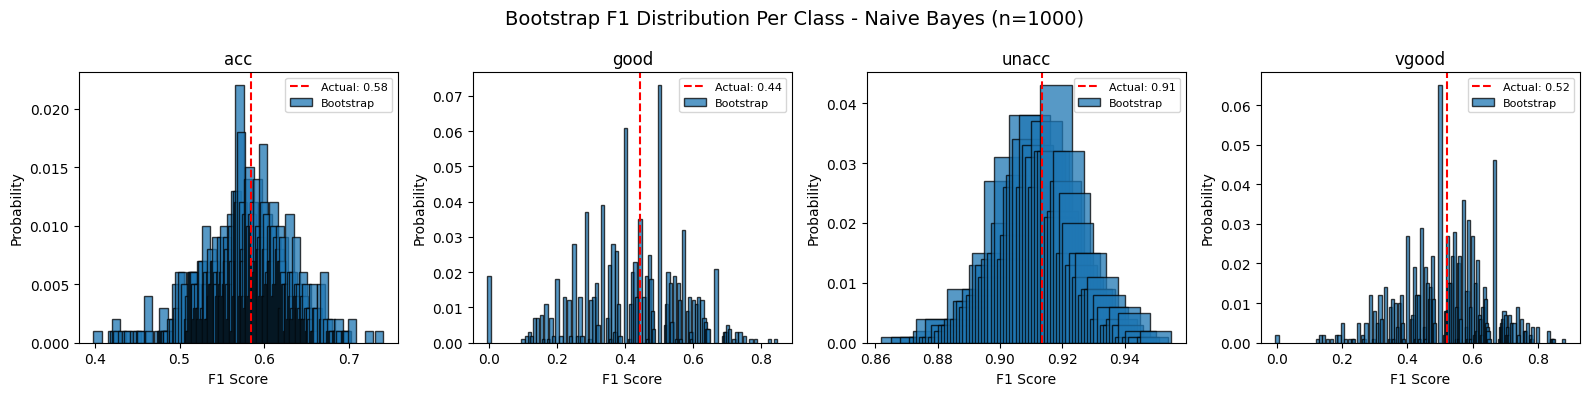

In [80]:
# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, n_classes, figsize=(4 * n_classes, 4), sharey=False)
fig.suptitle("Bootstrap F1 Distribution Per Class - Naive Bayes (n=1000)", fontsize=14)

for i, (ax, name) in enumerate(zip(axes, class_names)):
    scores_i = f1_scores_per_class_NB[i]
    total = len(scores_i)
    counts = Counter(scores_i)
    xs = sorted(counts.keys())
    probs = [counts[s] / total for s in xs]

    ax.bar(xs, probs, width=0.01, edgecolor='black', alpha=0.75, label='Bootstrap')
    ax.axvline(baseline_f1_per_class_NB[i], color='red', linestyle='--', linewidth=1.5,
               label=f'Actual: {baseline_f1_per_class_NB[i]:.2f}')

    ax.set_title(name)
    ax.set_xlabel("F1 Score")
    ax.set_ylabel("Probability")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [81]:
# ── One-hot encode + train Logistic Regression ────────────────────────────────
# Use same random_state=42 / test_size=0.2 as NB → identical row split
X_train_dev_raw, X_test_raw, _, _ = train_test_split(
    X_raw, y, test_size=0.2, random_state=42
)

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_train_dev_ohe = ohe.fit_transform(X_train_dev_raw)
X_test_ohe = ohe.transform(X_test_raw)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_dev_ohe)
X_test_scaled = scaler.transform(X_test_ohe)

modelLR = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
modelLR.fit(X_train_scaled, y_train_dev)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [82]:
# ── Classification report (Logistic Regression) ───────────────────────────────
baseline_preds_LR = modelLR.predict(X_test_scaled)
print(classification_report(y_test, baseline_preds_LR, target_names=class_names, zero_division=0))

              precision    recall  f1-score   support

         acc       0.89      0.81      0.85        83
        good       0.59      0.91      0.71        11
       unacc       0.96      0.97      0.97       235
       vgood       0.94      0.94      0.94        17

    accuracy                           0.93       346
   macro avg       0.85      0.91      0.87       346
weighted avg       0.93      0.93      0.93       346



In [83]:
# ── Baseline (real test set) ──────────────────────────────────────────────────
baseline_f1_per_class_LR = f1_score(y_test, baseline_preds_LR, average=None)
print("Baseline F1 per class (Logistic Regression):")
for name, score in zip(class_names, baseline_f1_per_class_LR):
    print(f"  {name}: {score:.4f}")

Baseline F1 per class (Logistic Regression):
  acc: 0.8481
  good: 0.7143
  unacc: 0.9661
  vgood: 0.9412


In [84]:
# f1_scores_per_class_LR[i] = list of 1000 bootstrap F1 scores for class i
np.random.seed(42)
f1_scores_per_class_LR = [[] for _ in range(n_classes)]

for _ in range(1000):
    indices = np.random.choice(len(X_test_scaled), size=len(X_test_scaled), replace=True)
    X_boot = X_test_scaled[indices]
    y_boot = y_test[indices]

    preds_LR = modelLR.predict(X_boot)
    per_class_LR = f1_score(y_boot, preds_LR, average=None, zero_division=0)

    for i, score in enumerate(per_class_LR):
        f1_scores_per_class_LR[i].append(round(score, 3))

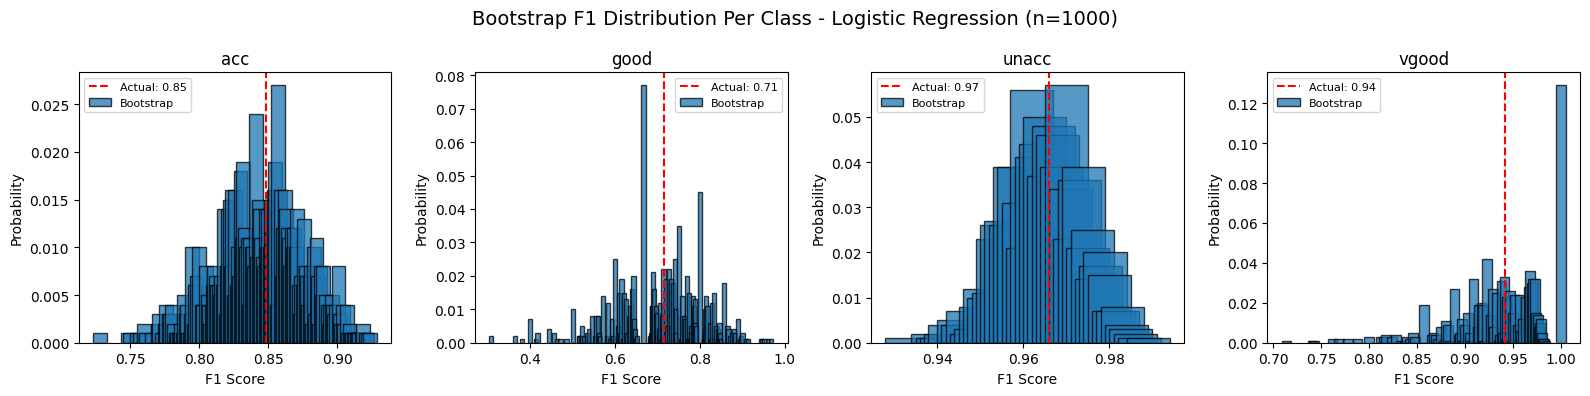

In [85]:
# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, n_classes, figsize=(4 * n_classes, 4), sharey=False)
fig.suptitle("Bootstrap F1 Distribution Per Class - Logistic Regression (n=1000)", fontsize=14)

for i, (ax, name) in enumerate(zip(axes, class_names)):
    scores_i = f1_scores_per_class_LR[i]
    total = len(scores_i)
    counts = Counter(scores_i)
    xs = sorted(counts.keys())
    probs = [counts[s] / total for s in xs]

    ax.bar(xs, probs, width=0.01, edgecolor='black', alpha=0.75, label='Bootstrap')
    ax.axvline(baseline_f1_per_class_LR[i], color='red', linestyle='--', linewidth=1.5,
               label=f'Actual: {baseline_f1_per_class_LR[i]:.2f}')

    ax.set_title(name)
    ax.set_xlabel("F1 Score")
    ax.set_ylabel("Probability")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

Real delta (NB − LR) per class:
  acc: -0.2637
  good: -0.2698
  unacc: -0.0526
  vgood: -0.4194


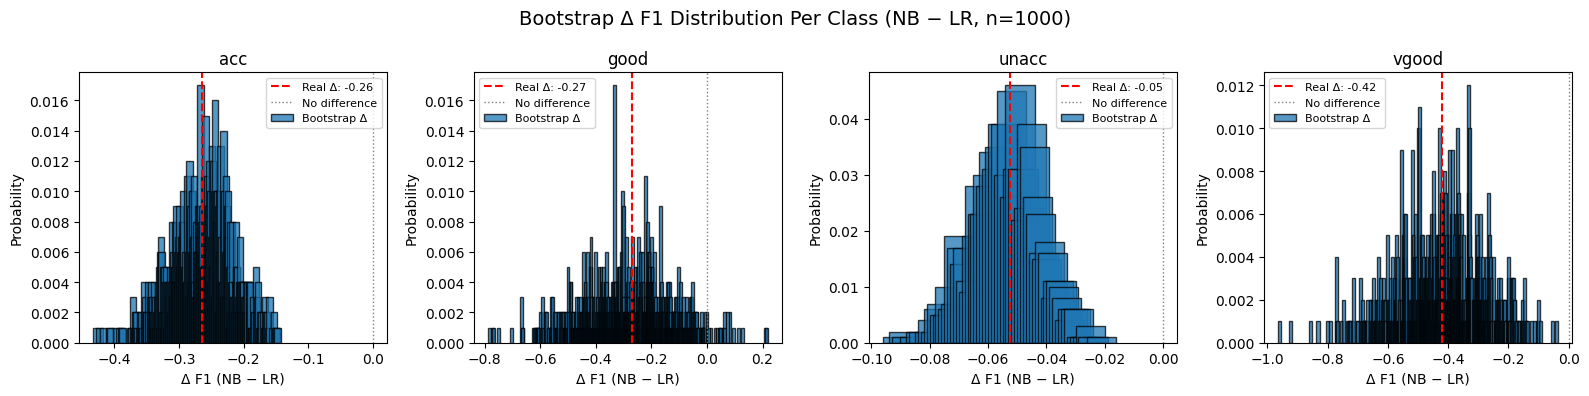

In [86]:
# ── Delta on real test set (NB - LR) ──────────────────────────────────────────
delta_real = baseline_f1_per_class_NB - baseline_f1_per_class_LR

print("Real delta (NB − LR) per class:")
for name, d in zip(class_names, delta_real):
    print(f"  {name}: {d:+.4f}")

# ── Paired bootstrap delta (same samples for both models) ─────────────────────
np.random.seed(42)
delta_boot_per_class = [[] for _ in range(n_classes)]

for _ in range(1000):
    indices = np.random.choice(len(X_test), size=len(X_test), replace=True)
    X_boot_NB = X_test[indices]
    X_boot_LR = X_test_scaled[indices]
    y_boot = y_test[indices]

    preds_NB = modelNB.predict(X_boot_NB)
    preds_LR = modelLR.predict(X_boot_LR)

    f1_NB_boot = f1_score(y_boot, preds_NB, average=None, zero_division=0)
    f1_LR_boot = f1_score(y_boot, preds_LR, average=None, zero_division=0)
    delta_boot = f1_NB_boot - f1_LR_boot

    for i, d in enumerate(delta_boot):
        delta_boot_per_class[i].append(round(d, 3))

# ── Plot delta distributions ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, n_classes, figsize=(4 * n_classes, 4), sharey=False)
fig.suptitle("Bootstrap Δ F1 Distribution Per Class (NB − LR, n=1000)", fontsize=14)

for i, (ax, name) in enumerate(zip(axes, class_names)):
    deltas_i = delta_boot_per_class[i]
    total = len(deltas_i)
    counts = Counter(deltas_i)
    xs = sorted(counts.keys())
    probs = [counts[d] / total for d in xs]

    ax.bar(xs, probs, width=0.01, edgecolor='black', alpha=0.75, label='Bootstrap Δ')
    ax.axvline(delta_real[i], color='red', linestyle='--', linewidth=1.5,
               label=f'Real Δ: {delta_real[i]:+.2f}')
    ax.axvline(0, color='gray', linestyle=':', linewidth=1.0, label='No difference')

    ax.set_title(name)
    ax.set_xlabel("Δ F1 (NB − LR)")
    ax.set_ylabel("Probability")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()